# 6주차: 논문 구현

## 금주 학습목표
* 논문 구현
    * Data Scraping
    * Generation of training sets

## 1. 데이터 확보

주식 상위 30개 코인 상위 10개 데이터 다운로드 및 정제

In [1]:
import yfinance as yf
import pandas as pd

sp500_tickers = [
    'NVDA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK-B',
    'WMT', 'LLY', 'JPM', 'XOM', 'JNJ', 'V', 'COST', 'MA', 'ORCL', 'NFLX',
    'MU', 'CVX', 'ABBV', 'PLTR', 'AMD', 'BAC', 'CAT', 'PG', 'KO', 'HD'
]

crypto_tickers = [
    'BTC-USD', 'ETH-USD', 'USDT-USD', 'XRP-USD', 'BNB-USD',
    'USDC-USD', 'SOL-USD', 'TRX-USD', 'DOGE-USD', 'HYPE-USD'
]

tickers = sp500_tickers + crypto_tickers

stock_data = yf.download(sp500_tickers, period='5y', interval='1d', auto_adjust=True)
crypto_data = yf.download(crypto_tickers, period='5y', interval='1d', auto_adjust=True)
data = pd.concat([stock_data, crypto_data], axis = 1)

[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  10 of 10 completed
C:\Users\skack\AppData\Local\Temp\ipykernel_30224\4206629555.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat([stock_data, crypto_data], axis = 1)


데이터 형태 확인

In [2]:
print("="*10,"data 형태 (행, 열):","="*10)
print(data.shape)
print("="*10,"columns","="*10)
print(data.columns[0:5])
print("="*10,"head","="*10)
print(data.head())


========== data 형태 (행, 열): ==========
(1827, 200)
========== columns ==========
MultiIndex([('Close', 'AAPL'),
            ('Close', 'ABBV'),
            ('Close',  'AMD'),
            ('Close', 'AMZN'),
            ('Close', 'AVGO')],
           names=['Price', 'Ticker'])
========== head ==========
Price            Close                                               \
Ticker            AAPL       ABBV        AMD        AMZN       AVGO   
Date                                                                  
2021-04-07  124.574028  86.888634  82.199997  163.969498  43.650158   
2021-04-08  126.970070  87.623634  83.349998  164.964996  43.923386   
2021-04-09  129.541412  88.812881  82.760002  168.610001  43.888100   
2021-04-10         NaN        NaN        NaN         NaN        NaN   
2021-04-11         NaN        NaN        NaN         NaN        NaN   

Price                                                                 ...  \
Ticker            BAC       BRK-B         CAT        

멀티 인덱스이므로 Feature 중 종가만 뜯어오기

In [3]:
stock_close = stock_data['Close']
crypto_close = crypto_data['Close']
data_close = data['Close']

데이터 형태 확인

In [4]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close.shape)
print("="*10,"columns","="*10)
print(data_close.columns[0:5])
print("="*10,"head","="*10)
print(data_close.head())
print("="*10,"결측 0나와야함","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1827, 40)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO'], dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-07  124.574028  86.888634  82.199997  163.969498  43.650158   
2021-04-08  126.970070  87.623634  83.349998  164.964996  43.923386   
2021-04-09  129.541412  88.812881  82.760002  168.610001  43.888100   
2021-04-10         NaN        NaN        NaN         NaN        NaN   
2021-04-11         NaN        NaN        NaN         NaN        NaN   

Ticker            BAC       BRK-B         CAT        COST        CVX  ...  \
Date                                                                  ...   
2021-04-07  35.469509  263.619995  210.136124  339.703369  84.606491  ...   
2021-04-08  35.159542  263.510010  210.199936  341.985016  83.656380  ...   
2021-04-

코인에 결측치 많음 확인  
어디서 발생했는지 체크

In [5]:
crypto_close.isnull().cumsum()

Ticker,BNB-USD,BTC-USD,DOGE-USD,ETH-USD,HYPE-USD,SOL-USD,TRX-USD,USDC-USD,USDT-USD,XRP-USD
Date,,,,,,,,,,
2021-04-07,0,0,0,0,0,0,0,0,0,0
2021-04-08,0,0,0,0,0,0,0,0,0,0
2021-04-09,0,0,0,0,0,0,0,0,0,0
2021-04-10,0,0,0,0,0,0,0,0,0,0
2021-04-11,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2026-04-02,0,0,0,0,583,0,0,0,0,0
2026-04-03,0,0,0,0,584,0,0,0,0,0
2026-04-04,0,0,0,0,585,0,0,0,0,0


In [ ]:
crypto_close['HYPE-USD'] #상폐 안됐는데 없음

Date
2021-04-07    3.440510
2021-04-08    2.892028
2021-04-09    2.885778
2021-04-10    2.747460
2021-04-11    2.780973
                ...   
2026-04-02         NaN
2026-04-03         NaN
2026-04-04         NaN
2026-04-05         NaN
2026-04-07         NaN
Name: HYPE-USD, Length: 1826, dtype: float64

yfinance에서 정보를 제공하지 않는 것 같음  
--> 회의 때 코인 하나 대체할 것 건의 필요

In [7]:
stock_close['AAPL'].head(10)

Date
2021-04-07    124.574028
2021-04-08    126.970070
2021-04-09    129.541412
2021-04-12    127.827171
2021-04-13    130.934250
2021-04-14    128.596634
2021-04-15    131.002441
2021-04-16    130.671234
2021-04-19    131.333603
2021-04-20    129.648560
Name: AAPL, dtype: float64

In [8]:
data_close['AAPL'].isnull().head(30)

Date
2021-04-07    False
2021-04-08    False
2021-04-09    False
2021-04-10     True
2021-04-11     True
2021-04-12    False
2021-04-13    False
2021-04-14    False
2021-04-15    False
2021-04-16    False
2021-04-17     True
2021-04-18     True
2021-04-19    False
2021-04-20    False
2021-04-21    False
2021-04-22    False
2021-04-23    False
2021-04-24     True
2021-04-25     True
2021-04-26    False
2021-04-27    False
2021-04-28    False
2021-04-29    False
2021-04-30    False
2021-05-01     True
2021-05-02     True
2021-05-03    False
2021-05-04    False
2021-05-05    False
2021-05-06    False
Freq: D, Name: AAPL, dtype: bool

나머지 데이터는 주말(주식)이 없음을 확인했고  
교수님의 조언에 따라 금요일 종가로 결측치 채움

In [9]:
# stock_close = stock_close.ffill().bfill()
crypto_close = crypto_close.drop(columns=['HYPE-USD'])
data_close = data_close.drop(columns=['HYPE-USD'])
data_close = data_close.ffill().bfill()

데이터 형태 확인

In [10]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close.shape)
print("="*10,"columns","="*10)
print(data_close.columns)
print("="*10,"head","="*10)
print(data_close.head())
print("="*10,"결측","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1827, 39)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO', 'BAC', 'BRK-B', 'CAT', 'COST',
       'CVX', 'GOOG', 'GOOGL', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'META',
       'MSFT', 'MU', 'NFLX', 'NVDA', 'ORCL', 'PG', 'PLTR', 'TSLA', 'V', 'WMT',
       'XOM', 'BNB-USD', 'BTC-USD', 'DOGE-USD', 'ETH-USD', 'SOL-USD',
       'TRX-USD', 'USDC-USD', 'USDT-USD', 'XRP-USD'],
      dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-07  124.574028  86.888634  82.199997  163.969498  43.650158   
2021-04-08  126.970070  87.623634  83.349998  164.964996  43.923386   
2021-04-09  129.541412  88.812881  82.760002  168.610001  43.888100   
2021-04-10  129.541412  88.812881  82.760002  168.610001  43.888100   
2021-04-11  129.541412  88.812881  82.760002  168.610001  43.888100   


원하는대로 잘 나와서 잘찍히는지 시각화해봄

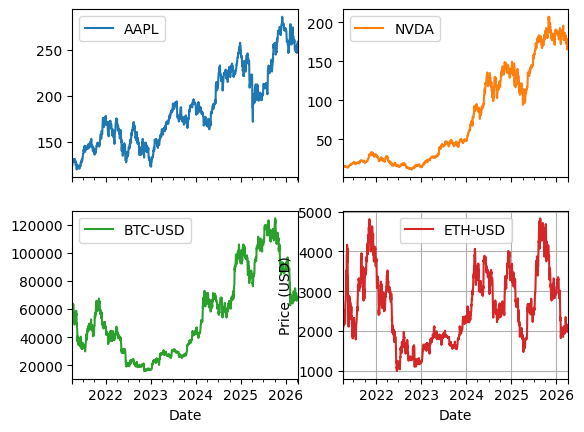

In [11]:
import matplotlib.pyplot as plt

data_close[['AAPL','NVDA','BTC-USD','ETH-USD']].plot.line(subplots=True, layout = (2,2))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

퍼센트로 바꿈

In [12]:
returns = data_close.pct_change()
stock_returns = stock_close.pct_change()
crypto_returns = crypto_close.pct_change()

returns = returns.dropna()
stock_returns = stock_close.dropna()
crypto_returns = crypto_close.dropna()

print(returns.head())

Ticker          AAPL      ABBV       AMD      AMZN      AVGO       BAC  \
Date                                                                     
2021-04-08  0.019234  0.008459  0.013990  0.006071  0.006259 -0.008739   
2021-04-09  0.020252  0.013572 -0.007079  0.022096 -0.000803  0.007305   
2021-04-10  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-04-11  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-04-12 -0.013233  0.006602 -0.050507  0.002132 -0.002927  0.001751   

Ticker         BRK-B       CAT      COST       CVX  ...       XOM   BNB-USD  \
Date                                                ...                       
2021-04-08 -0.000417  0.000304  0.006717 -0.011230  ... -0.010426  0.115784   
2021-04-09  0.009487  0.001171  0.005509 -0.000970  ... -0.002321  0.084059   
2021-04-10  0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.042769   
2021-04-11  0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.111785   
2021-04

In [24]:
heat = stock_returns.corr()
heat

Ticker,AAPL,ABBV,AMD,AMZN,AVGO,BAC,BRK-B,CAT,COST,CVX,...,MU,NFLX,NVDA,ORCL,PG,PLTR,TSLA,V,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.892092,0.772321,0.771376,0.912896,0.716453,0.897395,0.868273,0.894167,0.575168,...,0.699859,0.757776,0.930937,0.831794,0.739822,0.795913,0.673326,0.839634,0.907989,0.742477
ABBV,0.892092,1.000000,0.696157,0.640144,0.918234,0.657655,0.921465,0.876153,0.894855,0.733327,...,0.681756,0.719273,0.913981,0.821272,0.720137,0.816412,0.506381,0.848206,0.905826,0.845552
AMD,0.772321,0.696157,1.000000,0.718794,0.775446,0.680334,0.658944,0.811824,0.658641,0.371326,...,0.759217,0.616820,0.787077,0.682636,0.496118,0.665421,0.545459,0.631615,0.689572,0.535580
AMZN,0.771376,0.640144,0.718794,1.000000,0.813008,0.860580,0.774283,0.719109,0.796833,0.121313,...,0.599671,0.891978,0.847144,0.777575,0.574520,0.797542,0.685418,0.839395,0.810840,0.331115
AVGO,0.912896,0.918234,0.775446,0.813008,1.000000,0.806989,0.897552,0.922152,0.884190,0.551768,...,0.762039,0.862147,0.969295,0.908264,0.609983,0.947724,0.679421,0.905505,0.962217,0.711409
BAC,0.716453,0.657655,0.680334,0.860580,0.806989,1.000000,0.682310,0.753458,0.699027,0.203081,...,0.703684,0.807079,0.791295,0.716157,0.432774,0.835799,0.773307,0.722368,0.806619,0.331312
BRK-B,0.897395,0.921465,0.658944,0.774283,0.897552,0.682310,1.000000,0.818083,0.968585,0.584756,...,0.579127,0.848692,0.938934,0.845480,0.838143,0.804046,0.499339,0.946113,0.922304,0.758178
CAT,0.868273,0.876153,0.811824,0.719109,0.922152,0.753458,0.818083,1.000000,0.797567,0.625935,...,0.909795,0.706451,0.904618,0.749374,0.550780,0.835798,0.595898,0.786200,0.922931,0.783270
COST,0.894167,0.894855,0.658641,0.796833,0.884190,0.699027,0.968585,0.797567,1.000000,0.568806,...,0.571882,0.851688,0.942019,0.830571,0.852759,0.780798,0.523000,0.923877,0.919092,0.740615


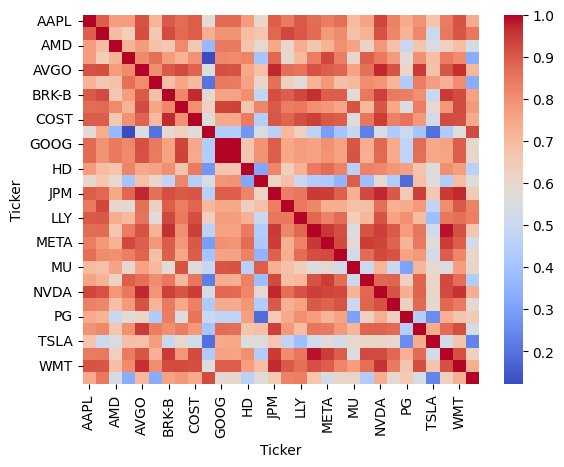

In [23]:
import seaborn as sns
sns.heatmap(heat, cmap='coolwarm')
plt.show()